In [1]:
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Dense, Dropout, MaxPooling2D, Conv2D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [3]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


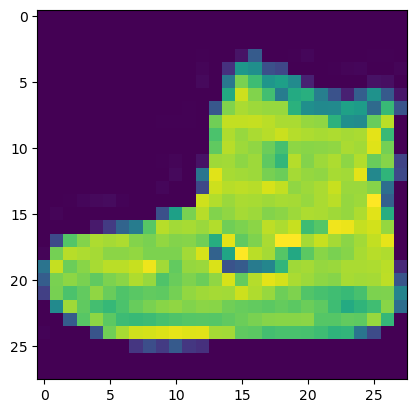

In [4]:
first_image = x_train[0]
plt.imshow(first_image)

In [5]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [6]:
x_train = x_train / 255
x_test = x_test / 255

In [7]:
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

In [8]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28, 1) (60000,)
(10000, 28, 28, 1) (10000,)


In [9]:
model = Sequential(
    [
        Conv2D(filters=32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ]
)

In [10]:
model.compile(loss='categorical_crossentropy', 
              optimizer='adam', metrics=['accuracy'])

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [12]:
model.fit(x_train, y_train_cat, epochs=10, verbose=1, 
          validation_data=(x_test, y_test_cat), callbacks=[early_stop])

Epoch 1/10
1875/1875 [==============================] - 13s 3ms/step - loss: 0.4126 - accuracy: 0.8533 - val_loss: 0.3244 - val_accuracy: 0.8844
Epoch 2/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2779 - accuracy: 0.8996 - val_loss: 0.2981 - val_accuracy: 0.8931
Epoch 3/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2361 - accuracy: 0.9143 - val_loss: 0.2756 - val_accuracy: 0.8988
Epoch 4/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2074 - accuracy: 0.9246 - val_loss: 0.2692 - val_accuracy: 0.9096
Epoch 5/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.1816 - accuracy: 0.9336 - val_loss: 0.2551 - val_accuracy: 0.9125
Epoch 6/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1617 - accuracy: 0.9399 - val_loss: 0.2647 - val_accuracy: 0.9095
Epoch 7/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.1434 - accuracy: 0.9476 - val_loss: 0.2587 - val_accuracy

<Axes: >

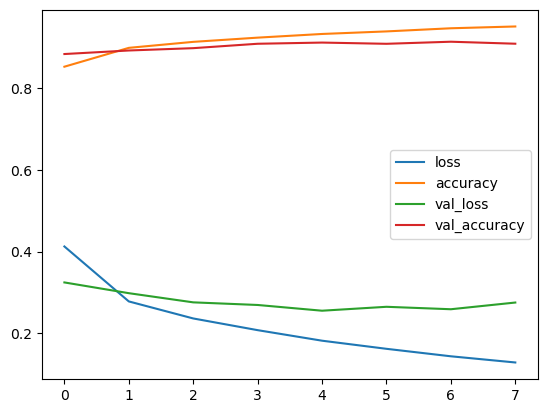

In [15]:
metrics = pd.DataFrame(model.history.history)
metrics[['loss', 'accuracy', 'val_loss', 'val_accuracy']].plot()

In [16]:
model.evaluate(x_test, y_test_cat, verbose=1)

313/313 [==============================] - 1s 3ms/step - loss: 0.2752 - accuracy: 0.9097


[0.27515870332717896, 0.9096999764442444]

In [18]:
predictions = model.predict(x_test)

313/313 [==============================] - 1s 2ms/step


In [19]:
predictions = np.argmax(predictions, axis=1)

In [20]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1000
           1       0.98      0.99      0.99      1000
           2       0.79      0.91      0.85      1000
           3       0.92      0.90      0.91      1000
           4       0.88      0.82      0.85      1000
           5       0.98      0.99      0.98      1000
           6       0.81      0.68      0.74      1000
           7       0.95      0.98      0.97      1000
           8       0.98      0.98      0.98      1000
           9       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



<Axes: >

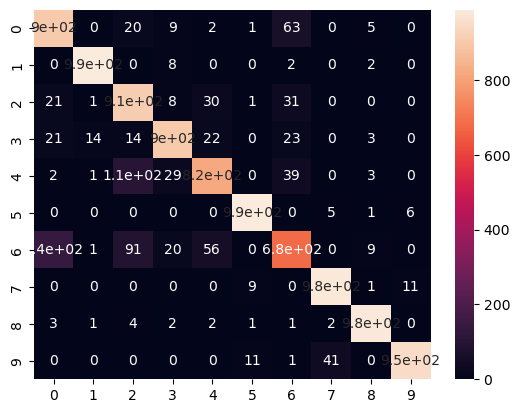

In [23]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True)

In [24]:
my_number = x_test[0]

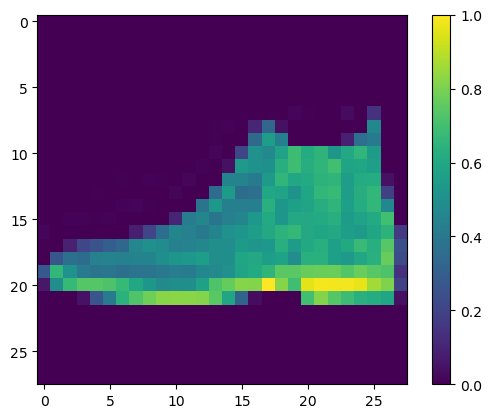

In [25]:
plt.imshow(my_number.reshape(28, 28))
plt.colorbar()
plt.show()

In [ ]:
my_number_reshape = my_number.reshape(1, 28, 28, 1)
predictions = model.predict(my_nu)